In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [2]:
## Loading Dataset

data = pd.read_csv(r"C:\Users\user\OneDrive\Documents\ML projects\customer.csv")

In [3]:
## Data Exploration
data.head(10)
data.info()
data.describe()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    100 non-null    int64  
 1   Call Failure             100 non-null    int64  
 2   Complaints               100 non-null    int64  
 3   Subscription Length      100 non-null    int64  
 4   Charge Amount            100 non-null    int64  
 5   Seconds of Use           100 non-null    int64  
 6   Frequency of use         100 non-null    int64  
 7   Frequency of SMS         100 non-null    int64  
 8   Distinct Called Numbers  100 non-null    int64  
 9   Age Group                100 non-null    int64  
 10  Tariff Plan              100 non-null    int64  
 11  Status                   100 non-null    int64  
 12  Age                      100 non-null    int64  
 13  Customer Value           100 non-null    float64
 14  Churn                    10

index                      0
Call Failure               0
Complaints                 0
Subscription Length        0
Charge Amount              0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [4]:
#Data Preprocessing
#Handling missing values
data.fillna(method='ffill', inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_11520\2951468656.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


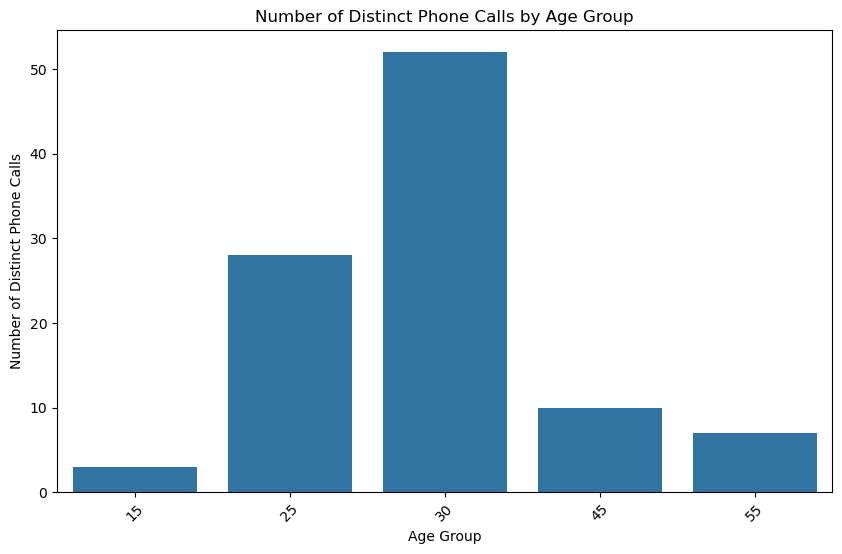

In [5]:
## Data Visualization 
#Create a plot visualizing the number of distinct phone calls by age group
plt.figure(figsize=(10,6))
sns.countplot(x='Age', data=data)
plt.title('Number of Distinct Phone Calls by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Distinct Phone Calls')
plt.xticks(rotation=45)
plt.show()


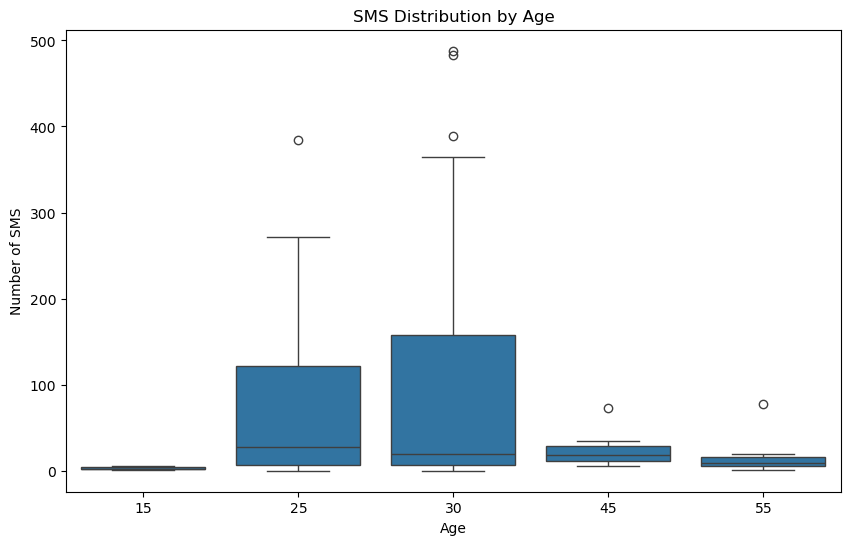

In [6]:
## Visualize the groups that send more SMS than make calls
plt.figure(figsize=(10,6))
sns.boxplot(x='Age', y='Frequency of SMS', data=data)
plt.title('SMS Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Number of SMS')
plt.show()

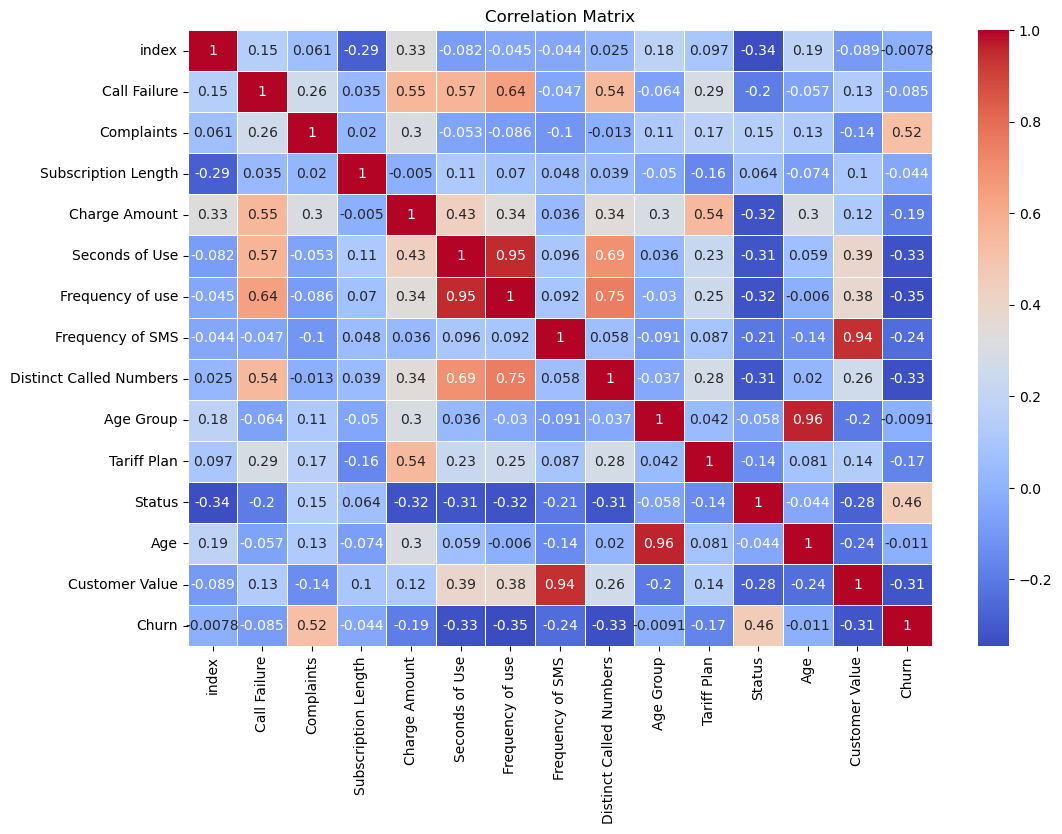

In [7]:
## correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [8]:
## drop irrelevant columns
data.drop(['index'], axis=1, inplace=True)

In [9]:
## Split the data into features and target variable
X = data.drop('Churn', axis=1)
y = data['Churn']


In [10]:
## Data preprocessing
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns


In [11]:
## Encoding categorical variables and scaling numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])


In [12]:
## Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
#Feature Scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])


In [14]:
## Model Building uing Logistic Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])


In [15]:
## Model Training
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Call Failure', 'Complaints', 'Subscription Length', 'Charge Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value'],
      dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index([], dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [16]:
## Model Evaluation
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.80      0.89         5

    accuracy                           0.95        20
   macro avg       0.97      0.90      0.93        20
weighted avg       0.95      0.95      0.95        20

Confusion Matrix:
 [[15  0]
 [ 1  4]]
Accuracy Score: 0.95


In [17]:
#Hyperparameter Tuning using GridSearchCV
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)   

print("Best Hyperparameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Classification Report for Best Model:\n", classification_report(y_test, y_pred_best))
print("Confusion Matrix for Best Model:\n", confusion_matrix(y_test, y_pred_best))
print("Accuracy Score for Best Model:", accuracy_score(y_test, y_pred_best))

Best Hyperparameters: {'classifier__C': 0.01, 'classifier__solver': 'liblinear'}
Classification Report for Best Model:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.80      0.89         5

    accuracy                           0.95        20
   macro avg       0.97      0.90      0.93        20
weighted avg       0.95      0.95      0.95        20

Confusion Matrix for Best Model:
 [[15  0]
 [ 1  4]]
Accuracy Score for Best Model: 0.95


In [18]:
# Undersampling the majority class
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)


In [19]:
## Penalization of the majority class
model_penalized = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
model_penalized.fit(X_train, y_train)
y_pred_penalized = model_penalized.predict(X_test)

In [20]:
## SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)


In [21]:
## install SHAP
!pip install shap

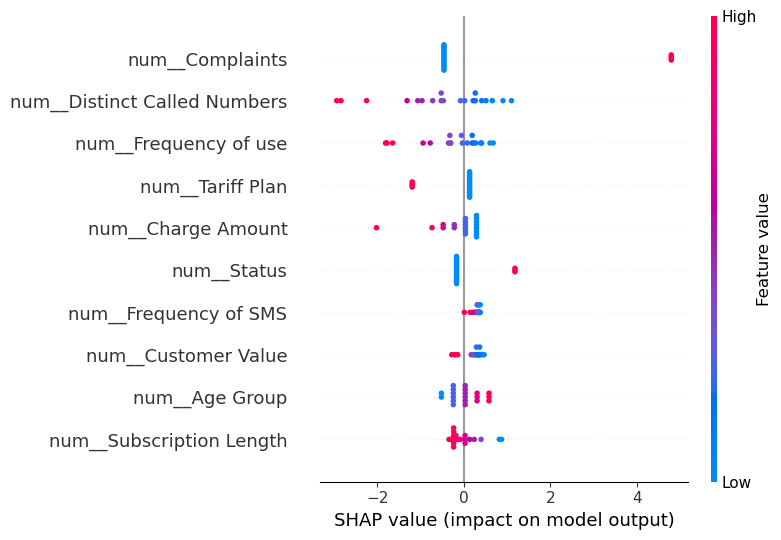

In [31]:
## Using SHAP for model interpretability
import shap
plt.figure()
X_shap = preprocessor.transform(X_test)
explainer = shap.Explainer(model.named_steps['classifier'], preprocessor.transform(X_train))
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(shap_values, X_shap, feature_names=preprocessor.get_feature_names_out(), max_display=10, show=False)
plt.savefig('shap_summary_plot.png', dpi =200, bbox_inches='tight')
plt.tight_layout()
plt.show()



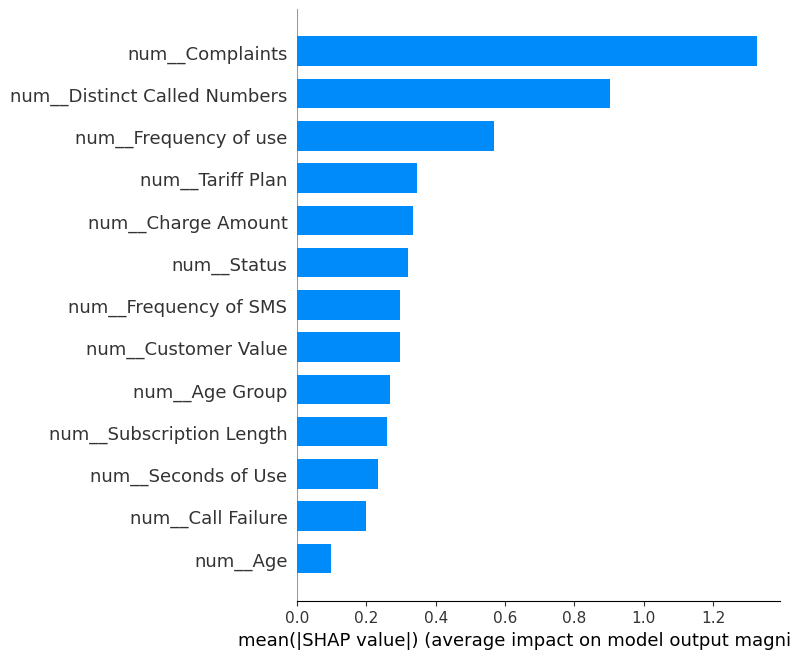

In [32]:
## SHAP feature importance
shap.summary_plot(shap_values, preprocessor.transform(X_test), feature_names=preprocessor.get_feature_names_out(), plot_type="bar")
